# Bucket 4 — Per-Pair IBKR Backtest & Hedge Grid

Isolates the **Bucket 4 v6 / IBKR** path from `Buckets1-4_v2.ipynb`:

- `run_bucket4_backtest_dynamic_h` (same engine as `Bucket_4_Backtest.ipynb` cell 14)
- IBKR / etf-dashboard borrow via `_v6_backtest_borrow_map`
- v6 portfolio **candidates** from `compute_v6_b4_pf_weight_dict`
- **dynamic_v7** hedge: VCR-driven `h` in **[0.3, 0.8]** with pair-specific bounds
- **Cadence policies**: fixed every 2–5 trading days, weekly baseline, TR/VCR (`continuous`, `signal_change`), `drift_deadband`

## 1. Setup (mirrors Buckets1-4_v2)

In [1]:
import importlib
import inspect
import pickle
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

warnings.filterwarnings("ignore")
pd.options.display.float_format = "{:,.4f}".format

TRADING_DAYS = 252


def norm_sym(x: str) -> str:
    return str(x).strip().upper().replace(".", "-")


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in (here, here.parent, *here.parents):
        if (p / "config" / "strategy_config.yml").exists() and (p / "scripts" / "gtp_sizing_mirror.py").exists():
            return p
    raise FileNotFoundError("Could not find repo root")


REPO_ROOT = find_repo_root()
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

with open(REPO_ROOT / "config" / "strategy_config.yml", "r", encoding="utf-8") as f:
    STRATEGY_CFG = yaml.safe_load(f) or {}
sleeves_cfg = (STRATEGY_CFG.get("portfolio") or {}).get("sleeves") or {}
b4_rules = (sleeves_cfg.get("inverse_decay_bucket4") or {}).get("rules") or {}
PARTIAL_HEDGE_YAML = float(b4_rules.get("partial_hedge_ratio", STRATEGY_CFG.get("b4_partial_hedge_ratio_default", 0.75)))

EXP = {
    "start_date": "2025-10-07",
    "end_date": None,
    "v6_b4_cache_path": str(NOTEBOOK_DIR / "v6_b4_gtp_cache.pkl"),
    "v6_b4_cache_rebuild": False,
    "v6_b4_allow_auto_bootstrap": True,
    "b4_resync_v6_rebal_weekly": True,
    "b4_weekly_warmup_bdays": 65,
    "b4_weekly_rebalance_freq": "W-FRI",
    "b4_weights_use_ibkr_uvix_borrow": True,
    "b4_drift_threshold_share_of_gross": 0.05,
    "b4_engine_fee_bps": 0.0,
    "b4_engine_slippage_bps": 20.0,
    "per_pair_initial_capital": 100_000.0,
    # dynamic_v7 hedge
    "v7_h_mid": 0.55,
    "v7_k_vcr": 1.0,
    "v7_smooth_alpha": 0.25,
    "v7_global_h_min": 0.30,
    "v7_global_h_max": 0.80,
    "v7_borrow_cap_h_max": 0.65,
    "v7_borrow_threshold": 0.50,
    # cadence (rebalancing) — hedge level fixed at dynamic_v7 in section 7
    "cadence_signal_window": 60,
    "cadence_lookahead_shift": 1,
    "cadence_hedge_method": "dynamic_v7",
    "cadence_apply_share_deadband": False,
    "cadence_every_n_days": [2, 3, 4, 5],
    "cont_base_days": 10.0,
    "cont_k_tr": 1.5,
    "cont_m_vcr": 2.0,
    "cont_min_interval": 2,
    "cont_max_interval": 42,
    "chg_d_tr": 0.10,
    "chg_d_vcr": 0.08,
    "chg_min_interval": 2,
    "chg_max_interval": 42,
    "drift_threshold_long": 0.15,
    "drift_threshold_short": 0.15,
    "v6_pf_params": {
        "decay_borrow_quad": 1,
        "borrow_linear_aversion": 3.0,
        "exclude_if_borrow_annual_gt": 0.9,
    },
}

SCREENED_PATH = REPO_ROOT / (STRATEGY_CFG.get("paths") or {}).get("screened_csv", "data/etf_screened_today.csv")
SCREENED = pd.read_csv(SCREENED_PATH)
for c in ("ETF", "Underlying"):
    SCREENED[c] = SCREENED[c].astype(str).map(norm_sym)

from scripts.gtp_dashboard_borrow import load_dashboard_borrow_avg_annual

DASHBOARD_BORROW_AVG, _ = load_dashboard_borrow_avg_annual()
if DASHBOARD_BORROW_AVG:
    _dash = SCREENED["ETF"].map(lambda s: DASHBOARD_BORROW_AVG.get(norm_sym(s), np.nan))
    for _col in ("borrow_current", "borrow_fee_annual", "borrow_avg_annual"):
        if _col not in SCREENED.columns:
            SCREENED[_col] = np.nan
        SCREENED[_col] = _dash.where(_dash.notna(), pd.to_numeric(SCREENED[_col], errors="coerce"))

BORROW_BY_ETF = {}
for _, r in SCREENED.iterrows():
    e = norm_sym(r["ETF"])
    b = r.get("borrow_avg_annual", np.nan)
    if not np.isfinite(b):
        b = r.get("borrow_current", np.nan)
    if np.isfinite(b):
        BORROW_BY_ETF[e] = float(max(0.0, b))

print(f"Repo: {REPO_ROOT}")
print(f"YAML partial_hedge_ratio: {PARTIAL_HEDGE_YAML:.2f}")

Repo: C:\Users\werdn\Documents\Investing\ls-algo
YAML partial_hedge_ratio: 0.75


## 2. Load v6 cache & IBKR borrow (Buckets1-4 cell 3)

In [2]:
import scripts.bucket4_dynamic_bt as _b4dyn
import scripts.bucket4_tail_portfolio as _b4tp
import scripts.v6_b4_pf_weights as _v6w

importlib.reload(_b4dyn)
importlib.reload(_b4tp)
importlib.reload(_v6w)

from scripts.bucket4_dynamic_bt import V6_OPT2_H_BASE, run_bucket4_backtest_dynamic_h
from scripts.bucket4_tail_portfolio import _etf_borrow_annual_actual
from scripts.v6_b4_pf_weights import V6PfParams, compute_v6_b4_pf_weight_dict


def _v6_backtest_borrow_map(symbols: list[str]) -> dict[str, float]:
    snap = globals().get("_V6_IBKR_BORROW_SNAPSHOT")
    out = {}
    for s in symbols:
        k = norm_sym(s)
        v = BORROW_BY_ETF.get(k)
        if v is None and isinstance(snap, dict):
            v = snap.get(k)
        if v is not None and np.isfinite(float(v)) and float(v) >= 0:
            out[k] = float(v)
    return out


def load_or_build_v6_globals() -> bool:
    cache_path = Path(EXP["v6_b4_cache_path"])
    if cache_path.exists() and not EXP.get("v6_b4_cache_rebuild"):
        try:
            with open(cache_path, "rb") as f:
                bundle = pickle.load(f)
            for k in ("_V6_PAIR_CACHE", "v6_opt2_h_daily_map", "V6_OPT2_H_BASE", "v6_opt2_rebal_index", "_V6_IBKR_BORROW_SNAPSHOT"):
                if k in bundle and bundle[k] is not None:
                    globals()[k] = bundle[k]
            if all(globals().get(k) is not None for k in ("_V6_PAIR_CACHE", "v6_opt2_h_daily_map", "V6_OPT2_H_BASE")):
                print(f"[v6] loaded {cache_path}")
                return True
        except Exception as e:
            print(f"[v6] cache load failed: {e}")
    if not EXP.get("v6_b4_allow_auto_bootstrap", True):
        return False
    from scripts.v6_bucket4_bootstrap_from_nb import ensure_v6_bucket4_globals_from_notebook

    print("[v6] bootstrapping from Bucket_4_Backtest.ipynb (slow)...")
    ensure_v6_bucket4_globals_from_notebook(globals(), repo_root=REPO_ROOT, screened_csv=SCREENED_PATH)
    etfs = {str(k[0]) for k, c in globals()["_V6_PAIR_CACHE"].items() if "skip_reason" not in c}
    etfs.add("UVIX")
    bundle = {
        "_V6_PAIR_CACHE": globals()["_V6_PAIR_CACHE"],
        "v6_opt2_h_daily_map": globals()["v6_opt2_h_daily_map"],
        "V6_OPT2_H_BASE": float(globals()["V6_OPT2_H_BASE"]),
        "v6_opt2_rebal_index": globals().get("v6_opt2_rebal_index"),
        "_V6_IBKR_BORROW_SNAPSHOT": _v6_backtest_borrow_map(sorted(etfs)),
    }
    with open(cache_path, "wb") as f:
        pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"[v6] cached {cache_path}")
    return True


assert load_or_build_v6_globals()

PAIR_CACHE = globals()["_V6_PAIR_CACHE"]
H_DAILY_MAP = globals()["v6_opt2_h_daily_map"]
H_BASE = float(globals().get("V6_OPT2_H_BASE", V6_OPT2_H_BASE))
REBAL_IX = pd.DatetimeIndex(globals()["v6_opt2_rebal_index"])

for c in PAIR_CACHE.values():
    if isinstance(c, dict) and isinstance(c.get("kw"), dict):
        c["kw"]["fee_bps"] = float(EXP["b4_engine_fee_bps"])
        c["kw"]["slippage_bps"] = float(EXP["b4_engine_slippage_bps"])

if EXP.get("b4_resync_v6_rebal_weekly"):
    from scripts.bucket4_weekly_opt2 import weekly_rebalance_dates

    u = set()
    for c in PAIR_CACHE.values():
        if isinstance(c, dict) and isinstance(c.get("prices"), pd.DataFrame):
            u.update(pd.to_datetime(c["prices"].index, errors="coerce").tolist())
    ix = pd.DatetimeIndex(sorted(u))
    REBAL_IX = weekly_rebalance_dates(ix, EXP["b4_weekly_rebalance_freq"], warmup_bdays=int(EXP["b4_weekly_warmup_bdays"]))
    print(f"[v6] rebal dates: {len(REBAL_IX)}")

_run_sig = inspect.signature(run_bucket4_backtest_dynamic_h)
_DRIFT_KW = (
    {"drift_threshold_share_of_gross": float(EXP["b4_drift_threshold_share_of_gross"])}
    if EXP.get("b4_drift_threshold_share_of_gross") is not None and "drift_threshold_share_of_gross" in _run_sig.parameters
    else {}
)

[v6] loaded C:\Users\werdn\Documents\Investing\ls-algo\notebooks\v6_b4_gtp_cache.pkl
[v6] rebal dates: 201


## 3. v6 portfolio candidates (Bucket 4)

In [3]:
_pf = EXP.get("v6_pf_params") or {}
p = V6PfParams(**{k: v for k, v in _pf.items() if k in V6PfParams.__dataclass_fields__})
_pf_kw = dict(
    pair_cache=PAIR_CACHE,
    v6_opt2_h_daily_map=H_DAILY_MAP,
    screened_csv=str(SCREENED_PATH),
    closes_broad=globals().get("closes_broad"),
    norm_sym=norm_sym,
    get_ibkr_borrow_map=_v6_backtest_borrow_map,
    opt2_h_base=H_BASE,
    params=p,
)
if "use_ibkr_uvix_borrow" in inspect.signature(compute_v6_b4_pf_weight_dict).parameters:
    _pf_kw["use_ibkr_uvix_borrow"] = bool(EXP.get("b4_weights_use_ibkr_uvix_borrow", True))
WEIGHTS, V6_DIAG, V6_META = compute_v6_b4_pf_weight_dict(**_pf_kw)
START_SIM = pd.Timestamp(V6_META["start_sim"])
CANDIDATE_KEYS = sorted(WEIGHTS.keys(), key=lambda k: (-WEIGHTS[k], f"{k[0]}/{k[1]}"))

cand_df = pd.DataFrame(
    [{"ETF": k[0], "Underlying": k[1], "v6_weight": WEIGHTS[k], "pair": f"{k[0]}/{k[1]}"} for k in CANDIDATE_KEYS]
)
print(f"start_sim={START_SIM.date()} | candidates={len(CANDIDATE_KEYS)} | decay={V6_META.get('decay_src_col')}")
display(cand_df)

start_sim=2025-10-07 | candidates=11 | decay=net_edge_p50_annual


,ETF,Underlying,v6_weight,pair
0,QBTZ,QBTS,0.1373,QBTZ/QBTS
1,ASTN,ASTS,0.1370,ASTN/ASTS
2,APLZ,APLD,0.1254,APLZ/APLD
3,IREZ,IREN,0.1231,IREZ/IREN
4,UVIX,SVIX,0.1129,UVIX/SVIX
5,SMZ,SMR,0.1115,SMZ/SMR
6,BEZ,BE,0.1080,BEZ/BE
7,CLSZ,CLSK,0.1019,CLSZ/CLSK
8,MSDD,MSTR,0.0154,MSDD/MSTR
9,CONI,COIN,0.0138,CONI/COIN


## 3b. TR/VCR signals & dynamic_v7 hedge

**Signals:** `etf-dashboard/data/vol_shape_history.json` (60d TR/VCR per ETF), shifted 1 day (no lookahead).

**dynamic_v7:** `h* = h_mid + k_vcr × (VCR − VCR_median)`, clipped to pair bounds and global **[0.3, 0.8]**, then optional EWM smooth.

signals: 11 sources={'history': 11} | v7 h series: 11


,pair,h_min,h_max,mean_h,min_h,max_h,corr_vcr_h
0,QBTZ/QBTS,0.30,0.65,0.54,0.50,0.60,0.96
1,ASTN/ASTS,0.30,0.65,0.55,0.55,0.57,nan
2,APLZ/APLD,0.30,0.80,0.55,0.55,0.60,0.56
3,IREZ/IREN,0.30,0.65,0.56,0.55,0.62,0.46
4,UVIX/SVIX,0.30,0.80,0.55,0.48,0.62,0.91
5,SMZ/SMR,0.30,0.80,0.55,0.55,0.55,nan
6,BEZ/BE,0.30,0.65,0.55,0.55,0.55,nan
7,CLSZ/CLSK,0.30,0.80,0.55,0.55,0.55,nan
8,MSDD/MSTR,0.30,0.80,0.61,0.53,0.72,0.97
9,CONI/COIN,0.30,0.65,0.52,0.46,0.65,0.89


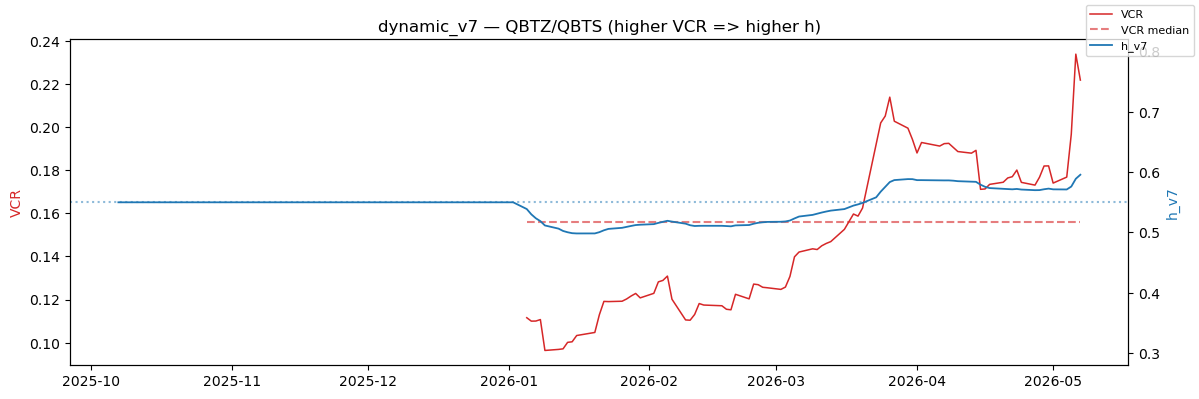

In [4]:
import scripts.bucket4_vol_shape_signals as _vss
import scripts.bucket4_hedge_v7 as _h7

importlib.reload(_vss)
importlib.reload(_h7)
from scripts.bucket4_vol_shape_signals import get_pair_signal, load_vol_shape_history
from scripts.bucket4_hedge_v7 import (
    V7_GLOBAL_H_MAX,
    V7_GLOBAL_H_MIN,
    build_h_v7_by_pair,
    default_v7_pair_bounds_from_screened,
    resolve_pair_h_bounds,
)

VOL_SHAPE_HISTORY_PATH = REPO_ROOT.parent / "etf-dashboard" / "data" / "vol_shape_history.json"
VS_HISTORY = load_vol_shape_history(VOL_SHAPE_HISTORY_PATH, norm_sym=norm_sym)

SIGNALS: dict[tuple[str, str], pd.DataFrame] = {}
_src_counts: dict[str, int] = {}
for key in CANDIDATE_KEYS:
    etf, und = key
    c = PAIR_CACHE.get(key) or {}
    prices_i = c.get("prices")
    if not isinstance(prices_i, pd.DataFrame) or prices_i.empty:
        continue
    cal = prices_i.loc[prices_i.index >= START_SIM].index
    und_px = prices_i["b_px"] if "b_px" in prices_i.columns else None
    sig = get_pair_signal(
        etf,
        und,
        cal,
        history=VS_HISTORY,
        underlying_prices=und_px,
        window=int(EXP["cadence_signal_window"]),
        lookahead_shift=int(EXP["cadence_lookahead_shift"]),
        norm_sym=norm_sym,
    )
    SIGNALS[key] = sig
    s = sig.attrs.get("signal_source", "?")
    _src_counts[s] = _src_counts.get(s, 0) + 1

V7_PAIR_BOUNDS = EXP.get("v7_pair_bounds")
if not V7_PAIR_BOUNDS:
    V7_PAIR_BOUNDS = default_v7_pair_bounds_from_screened(
        SCREENED,
        CANDIDATE_KEYS,
        global_h_min=float(EXP["v7_global_h_min"]),
        global_h_max=float(EXP["v7_global_h_max"]),
        high_borrow_cap_h_max=float(EXP["v7_borrow_cap_h_max"]),
        borrow_threshold=float(EXP["v7_borrow_threshold"]),
        norm_sym=norm_sym,
    )

H_V7_BY_PAIR = build_h_v7_by_pair(
    SIGNALS,
    PAIR_CACHE,
    start_sim=START_SIM,
    pair_bounds=V7_PAIR_BOUNDS,
    h_mid=float(EXP["v7_h_mid"]),
    k_vcr=float(EXP["v7_k_vcr"]),
    global_h_min=float(EXP["v7_global_h_min"]),
    global_h_max=float(EXP["v7_global_h_max"]),
    smooth_alpha=float(EXP["v7_smooth_alpha"]),
    norm_sym=norm_sym,
)

bounds_rows = []
for key in CANDIDATE_KEYS:
    if key not in H_V7_BY_PAIR:
        continue
    lo, hi = resolve_pair_h_bounds(
        key[0], key[1], pair_bounds=V7_PAIR_BOUNDS,
        global_h_min=float(EXP["v7_global_h_min"]), global_h_max=float(EXP["v7_global_h_max"]), norm_sym=norm_sym,
    )
    h = H_V7_BY_PAIR[key]
    vcr = SIGNALS[key]["vcr"].reindex(h.index).ffill()
    bounds_rows.append({
        "pair": f"{key[0]}/{key[1]}",
        "h_min": lo, "h_max": hi,
        "mean_h": float(h.mean()), "min_h": float(h.min()), "max_h": float(h.max()),
        "corr_vcr_h": float(vcr.corr(h)) if vcr.notna().sum() > 5 else np.nan,
    })

print(f"signals: {len(SIGNALS)} sources={_src_counts} | v7 h series: {len(H_V7_BY_PAIR)}")
display(pd.DataFrame(bounds_rows).style.format({"h_min": "{:.2f}", "h_max": "{:.2f}", "mean_h": "{:.2f}", "min_h": "{:.2f}", "max_h": "{:.2f}", "corr_vcr_h": "{:.2f}"}))

# Top-weight pair: VCR vs h_v7
_top = CANDIDATE_KEYS[0]
if _top in H_V7_BY_PAIR:
    fig, ax1 = plt.subplots(figsize=(12, 4))
    sig = SIGNALS[_top]
    h = H_V7_BY_PAIR[_top]
    ax1.plot(sig.index, sig["vcr"], color="tab:red", lw=1.1, label="VCR")
    ax1.plot(sig.index, sig["vcr_med"], color="tab:red", ls="--", alpha=0.6, label="VCR median")
    ax1.set_ylabel("VCR", color="tab:red")
    ax2 = ax1.twinx()
    ax2.plot(h.index, h.values, color="tab:blue", lw=1.3, label="h_v7")
    ax2.axhline(float(EXP["v7_h_mid"]), color="tab:blue", ls=":", alpha=0.5)
    ax2.set_ylim(float(EXP["v7_global_h_min"]) - 0.02, float(EXP["v7_global_h_max"]) + 0.02)
    ax2.set_ylabel("h_v7", color="tab:blue")
    ax1.set_title(f"dynamic_v7 — {_top[0]}/{_top[1]} (higher VCR => higher h)")
    fig.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

## 4. Hedge methods & per-pair engine

Each method supplies a daily **h** series for `run_bucket4_backtest_dynamic_h`:

`target_share_a = 1 / (1 + h × |β_inverse|)` (both legs short).

| Method | Description |
|--------|-------------|
| `dynamic_v7` | **Primary:** VCR vs median → h ∈ [0.3, 0.8], pair bounds |
| `dynamic_v6` | Legacy Opt-2 cross-sectional hedge from v6 cache |
| `static_h_0.55` | Constant anchor at `v7_h_mid` |

In [5]:
def build_hedge_methods() -> dict[str, str]:
    return {
        "dynamic_v7": "VCR-driven h [0.3,0.8], pair bounds",
        "dynamic_v6": "Opt-2 dynamic h (legacy)",
        "static_h_0.55": f"h={float(EXP.get('v7_h_mid', 0.55)):.2f} anchor",
    }


def resolve_h_series(method: str, key: tuple[str, str], price_index: pd.DatetimeIndex) -> pd.Series:
    etf_sym, und_sym = key
    if method == "dynamic_v7":
        ser = H_V7_BY_PAIR.get(key)
        if ser is None or getattr(ser, "empty", True):
            raise KeyError(f"no v7 h for {key}")
        return ser.reindex(price_index).ffill().fillna(float(EXP["v7_h_mid"]))
    if method == "dynamic_v6":
        ser = H_DAILY_MAP.get(norm_sym(und_sym))
        if ser is None or getattr(ser, "empty", True):
            raise KeyError(f"no v6 h series for {und_sym}")
        return ser.reindex(price_index).ffill().fillna(H_BASE)
    if method == "static_yaml":
        h_const = float(PARTIAL_HEDGE_YAML)
    elif method.startswith("static_h_"):
        h_const = float(method.split("_")[-1])
    else:
        raise ValueError(method)
    return pd.Series(h_const, index=price_index, dtype=float)


def _uvix_borrow_base() -> float | None:
    if not EXP.get("b4_weights_use_ibkr_uvix_borrow", True):
        return None
    try:
        m = _v6_backtest_borrow_map(["UVIX"])
        v = m.get("UVIX")
        if v is not None and np.isfinite(float(v)) and float(v) > 0:
            return float(v)
    except Exception:
        pass
    return None


UVIX_BORROW = _uvix_borrow_base()


def run_single_pair_backtest(
    key: tuple[str, str],
    method: str,
    *,
    initial_capital: float | None = None,
) -> pd.DataFrame | None:
    """One pair, one hedge method — mirrors aggregate_tail_risk_weighted_portfolio inner loop."""
    if key not in PAIR_CACHE or "skip_reason" in PAIR_CACHE[key]:
        return None
    etf_sym, und_sym = key
    c = PAIR_CACHE[key]
    prices_i = c["prices"].loc[c["prices"].index >= START_SIM]
    if prices_i.empty:
        return None
    kw = dict(c["kw"])
    kw["initial_capital"] = float(initial_capital or EXP["per_pair_initial_capital"])
    kw["borrow_a_annual"] = _etf_borrow_annual_actual(
        etf_sym, kw, uvix_borrow_annual_base=UVIX_BORROW, norm_sym=norm_sym
    )
    kw.update(_DRIFT_KW)
    h_d = resolve_h_series(method, key, prices_i.index)
    pair_rebal = REBAL_IX.intersection(prices_i.index)
    if len(pair_rebal) == 0:
        pair_rebal = pd.DatetimeIndex([prices_i.index[0]])
    return run_bucket4_backtest_dynamic_h(prices_i, h_d, pair_rebal, **kw)


def pair_metrics(bt: pd.DataFrame) -> dict[str, float]:
    """CAGR / vol / max_dd on standalone sub-account equity (same span logic as Buckets1-4)."""
    nav = bt["equity"].astype(float)
    rets = nav.pct_change().iloc[1:].dropna()
    span_days = max(int((nav.index[-1] - nav.index[0]).days), 0)
    years = max(span_days / 365.25, 1.0 / 365.25)
    n0, n1 = float(nav.iloc[0]), float(nav.iloc[-1])
    cagr = (n1 / n0) ** (1.0 / years) - 1.0 if n0 > 1e-9 else np.nan
    if len(rets) > 2:
        sd = float(rets.std(ddof=1))
        vol = sd * np.sqrt(TRADING_DAYS) if sd > 1e-18 else np.nan
    else:
        vol = np.nan
    dd = nav / nav.cummax() - 1.0
    return {"CAGR": cagr, "vol": vol, "max_dd": float(dd.min()), "final_equity": n1}


HEDGE_METHODS = build_hedge_methods()
print("Hedge methods:", list(HEDGE_METHODS.keys()))

Hedge methods: ['dynamic_v7', 'dynamic_v6', 'static_h_0.55']


## 5. Run grid (all pairs × hedge methods)

In [6]:
rows = []
bt_store: dict[tuple[str, str, str], pd.DataFrame] = {}

for key in CANDIDATE_KEYS:
    pair_lab = f"{key[0]}/{key[1]}"
    for method in HEDGE_METHODS:
        try:
            bt = run_single_pair_backtest(key, method)
        except Exception as ex:
            print(f"SKIP {pair_lab} {method}: {ex}")
            continue
        if bt is None or bt.empty:
            continue
        m = pair_metrics(bt)
        bt_store[(pair_lab, method)] = bt
        rows.append(
            {
                "pair": pair_lab,
                "ETF": key[0],
                "Underlying": key[1],
                "hedge_method": method,
                "hedge_label": HEDGE_METHODS[method],
                "v6_weight": WEIGHTS[key],
                **m,
                "mean_h": float(bt["h_used"].mean()) if "h_used" in bt.columns else np.nan,
                "borrow_paid": float(bt["borrow_cost"].sum()) if "borrow_cost" in bt.columns else np.nan,
            }
        )

RESULTS = pd.DataFrame(rows)
if RESULTS.empty:
    raise RuntimeError("No backtests completed — check v6 cache and candidates.")

RESULTS = RESULTS.sort_values(["pair", "hedge_method"]).reset_index(drop=True)
print(f"Completed {len(RESULTS)} runs ({len(CANDIDATE_KEYS)} pairs × {len(HEDGE_METHODS)} methods)")
display(
    RESULTS[
        ["pair", "hedge_method", "CAGR", "vol", "max_dd", "mean_h", "v6_weight", "borrow_paid"]
    ].style.format({"CAGR": "{:.2%}", "vol": "{:.2%}", "max_dd": "{:.2%}", "mean_h": "{:.3f}", "v6_weight": "{:.3f}"})
)

Completed 33 runs (11 pairs × 3 methods)


,pair,hedge_method,CAGR,vol,max_dd,mean_h,v6_weight,borrow_paid
0,APLZ/APLD,dynamic_v6,234.56%,50.50%,-14.26%,0.626,0.125,4937.251821
1,APLZ/APLD,dynamic_v7,258.11%,68.59%,-19.38%,0.555,0.125,5320.261927
2,APLZ/APLD,static_h_0.55,264.22%,68.73%,-19.38%,0.550,0.125,5335.998470
3,ASTN/ASTS,dynamic_v6,-10.11%,32.97%,-12.25%,0.687,0.137,5083.431701
4,ASTN/ASTS,dynamic_v7,-23.05%,45.15%,-18.16%,0.550,0.137,5643.524318
5,ASTN/ASTS,static_h_0.55,-23.04%,45.15%,-18.16%,0.550,0.137,5643.524318
6,BEZ/BE,dynamic_v6,119.57%,27.91%,-6.69%,0.681,0.108,7251.481951
7,BEZ/BE,dynamic_v7,197.63%,46.74%,-11.48%,0.550,0.108,8324.526157
8,BEZ/BE,static_h_0.55,197.63%,46.74%,-11.48%,0.550,0.108,8324.526157
9,CLSZ/CLSK,dynamic_v6,267.72%,32.75%,-6.59%,0.538,0.102,1138.834540


## 6. Plots — CAGR / vol / max drawdown by pair

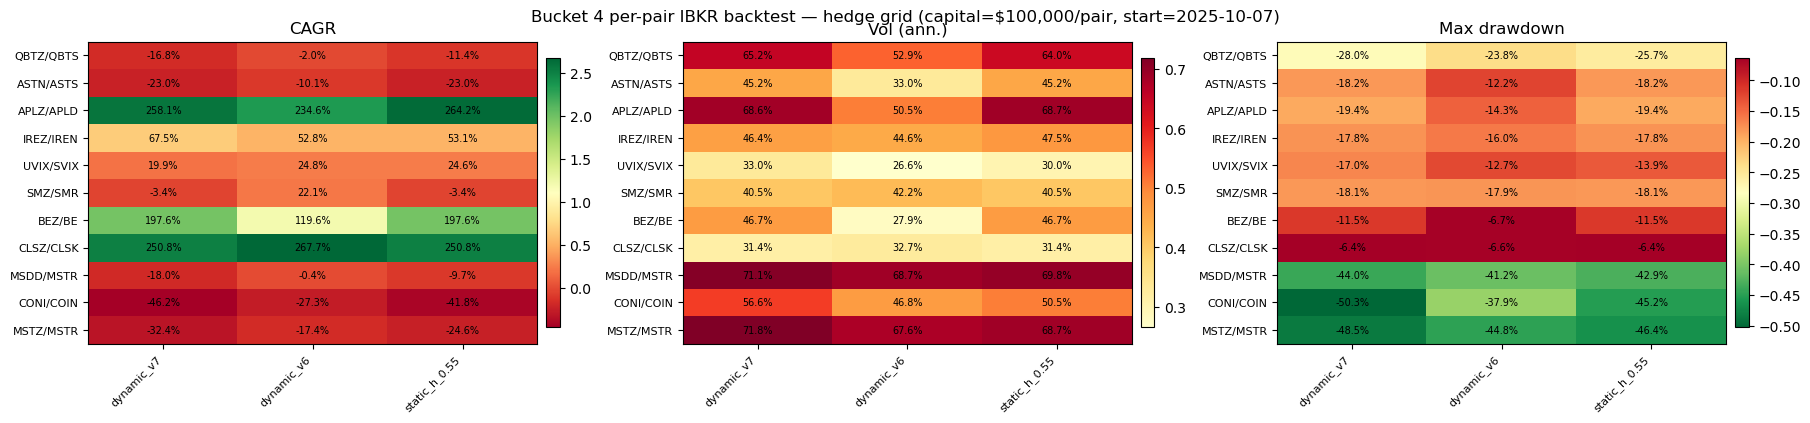

In [7]:
pairs_order = [f"{k[0]}/{k[1]}" for k in CANDIDATE_KEYS]
methods_order = list(HEDGE_METHODS.keys())


def metric_pivot(metric: str) -> pd.DataFrame:
    p = RESULTS.pivot(index="pair", columns="hedge_method", values=metric)
    return p.reindex(index=pairs_order, columns=methods_order)


pv_cagr = metric_pivot("CAGR")
pv_vol = metric_pivot("vol")
pv_dd = metric_pivot("max_dd")

fig, axes = plt.subplots(1, 3, figsize=(18, max(4.0, 0.35 * len(pairs_order))), constrained_layout=True)
for ax, pv, title, cmap in zip(
    axes,
    [pv_cagr, pv_vol, pv_dd],
    ["CAGR", "Vol (ann.)", "Max drawdown"],
    ["RdYlGn", "YlOrRd", "RdYlGn_r"],
):
    data = pv.astype(float).values
    im = ax.imshow(data, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(methods_order)))
    ax.set_xticklabels(methods_order, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(pairs_order)))
    ax.set_yticklabels(pairs_order, fontsize=8)
    ax.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.1%}", ha="center", va="center", fontsize=7, color="black")
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
fig.suptitle(
    f"Bucket 4 per-pair IBKR backtest — hedge grid (capital=${EXP['per_pair_initial_capital']:,.0f}/pair, start={START_SIM.date()})",
    fontsize=12,
    y=1.02,
)
plt.show()

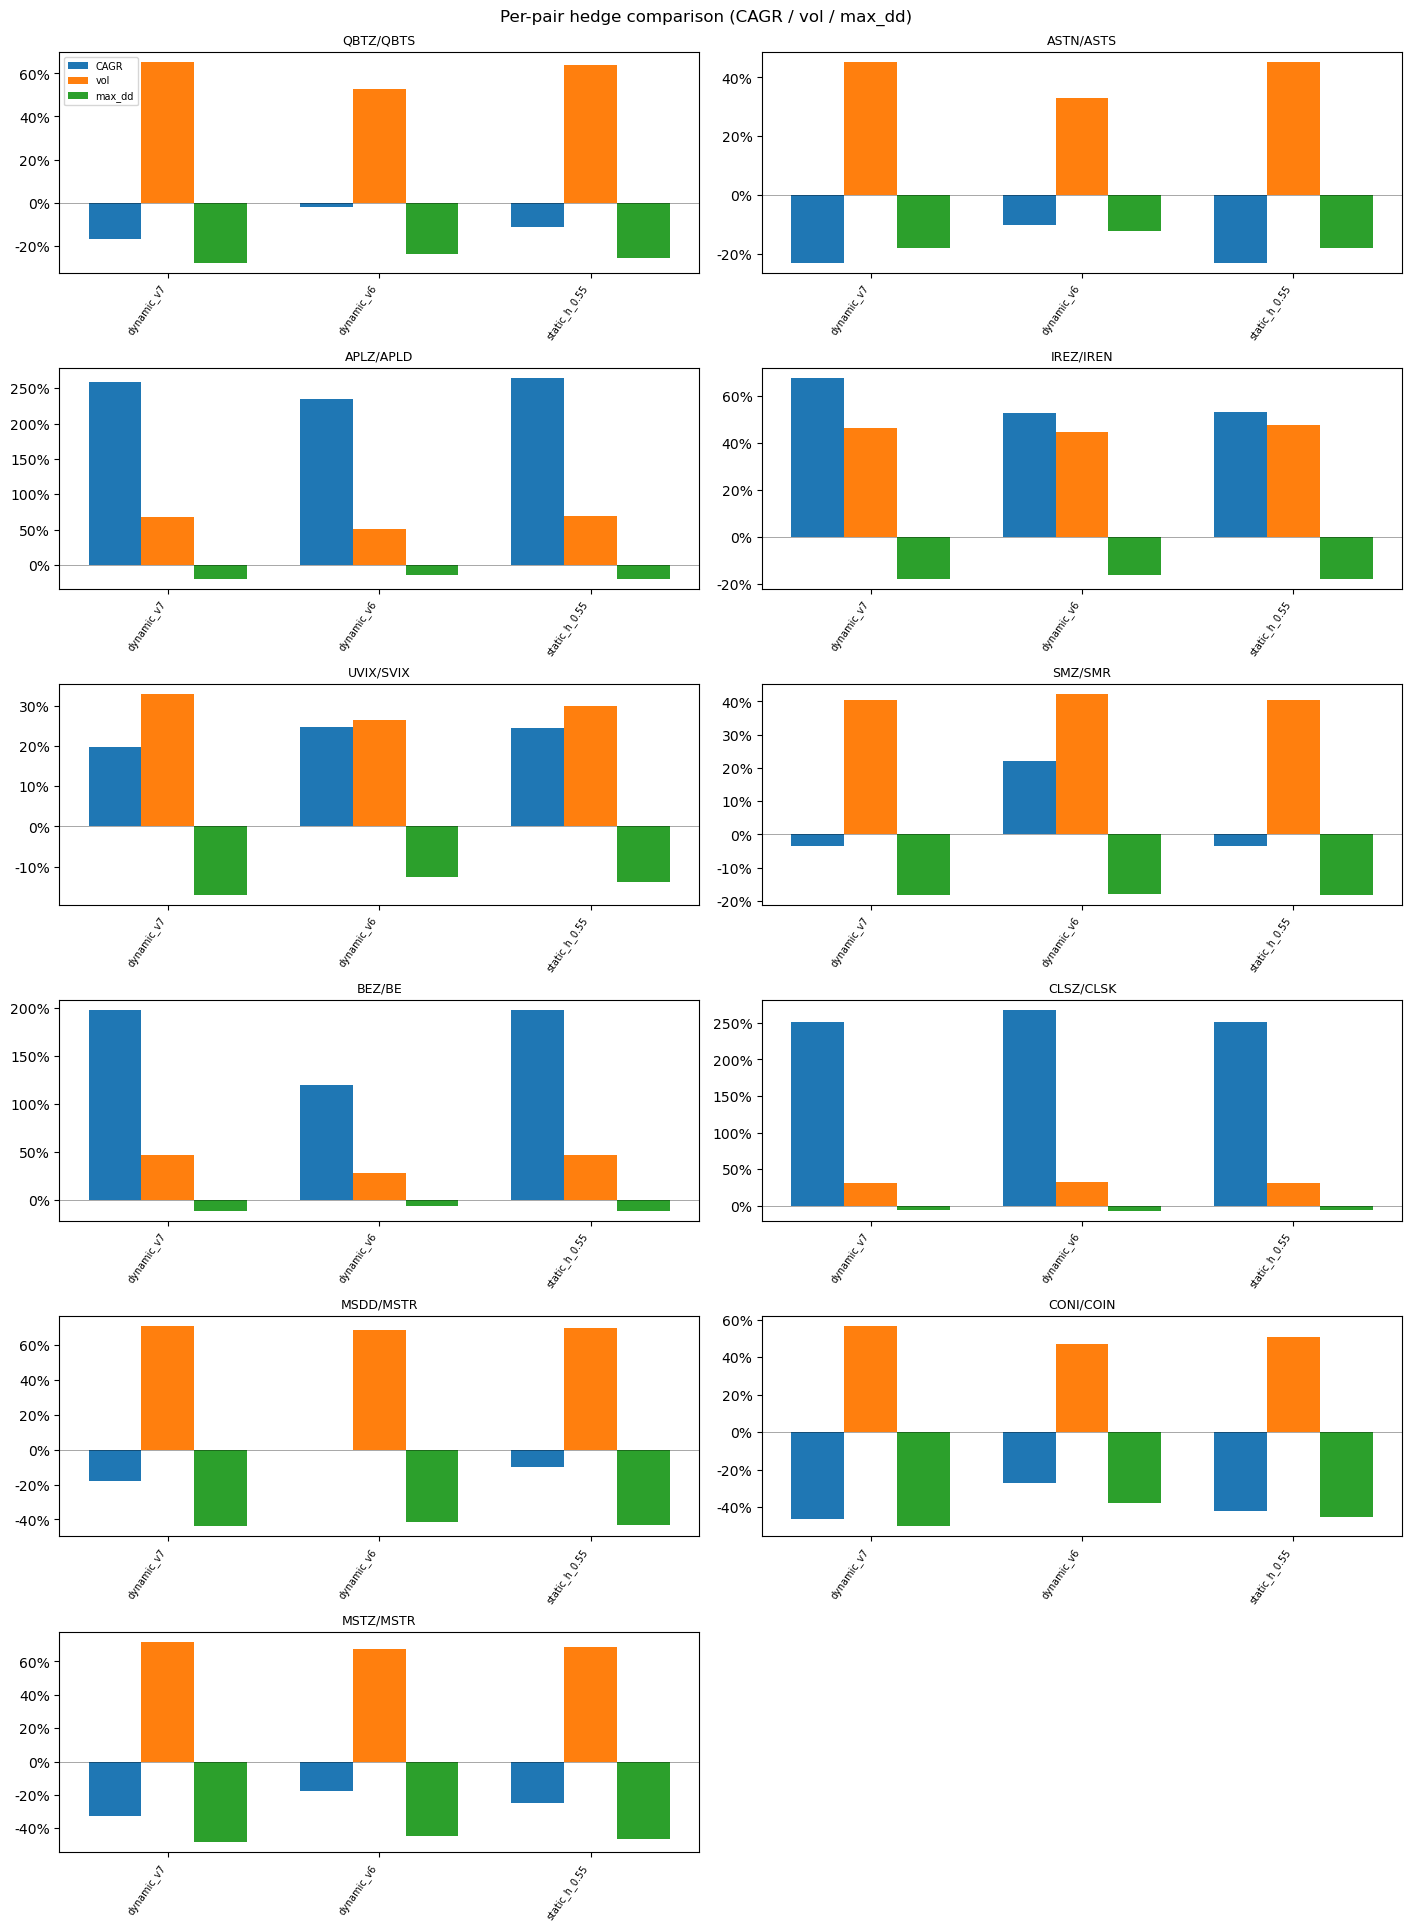

In [8]:
n_pairs = len(pairs_order)
ncols = 2
nrows = int(np.ceil(n_pairs / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), constrained_layout=True)
axes_flat = np.atleast_1d(axes).ravel()
x = np.arange(len(methods_order))
w = 0.25

for i, pair_lab in enumerate(pairs_order):
    ax = axes_flat[i]
    sub = RESULTS[RESULTS["pair"] == pair_lab].set_index("hedge_method").reindex(methods_order)
    cagr = sub["CAGR"].astype(float).values
    vol = sub["vol"].astype(float).values
    dd = sub["max_dd"].astype(float).values
    ax.bar(x - w, cagr, width=w, label="CAGR")
    ax.bar(x, vol, width=w, label="vol")
    ax.bar(x + w, dd, width=w, label="max_dd")
    ax.axhline(0, color="k", lw=0.6, alpha=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(methods_order, rotation=55, ha="right", fontsize=7)
    ax.set_title(pair_lab, fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    if i == 0:
        ax.legend(fontsize=7, loc="upper left")

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Per-pair hedge comparison (CAGR / vol / max_dd)", fontsize=12)
plt.show()

Best CAGR hedge per pair:


,pair,hedge_method,CAGR,vol,max_dd
0,APLZ/APLD,static_h_0.55,264.22%,68.73%,-19.38%
1,ASTN/ASTS,dynamic_v6,-10.11%,32.97%,-12.25%
2,BEZ/BE,dynamic_v7,197.63%,46.74%,-11.48%
3,CLSZ/CLSK,dynamic_v6,267.72%,32.75%,-6.59%
4,CONI/COIN,dynamic_v6,-27.26%,46.79%,-37.94%
5,IREZ/IREN,dynamic_v7,67.50%,46.35%,-17.75%
6,MSDD/MSTR,dynamic_v6,-0.40%,68.72%,-41.18%
7,MSTZ/MSTR,dynamic_v6,-17.42%,67.57%,-44.78%
8,QBTZ/QBTS,dynamic_v6,-1.98%,52.91%,-23.81%
9,SMZ/SMR,dynamic_v6,22.14%,42.21%,-17.91%


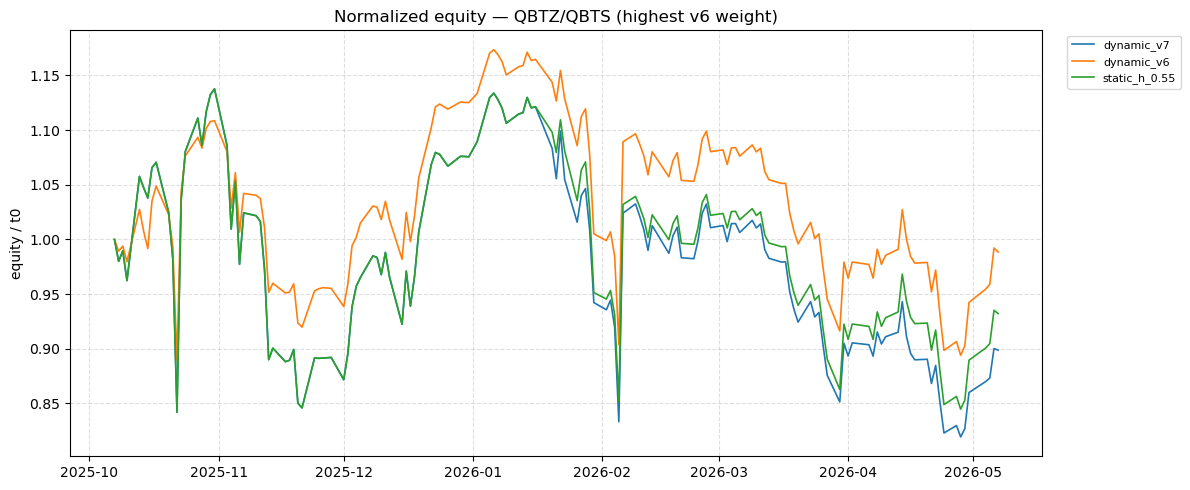

In [9]:
best = (
    RESULTS.sort_values("CAGR", ascending=False)
    .groupby("pair", as_index=False)
    .first()[["pair", "hedge_method", "CAGR", "vol", "max_dd"]]
)
print("Best CAGR hedge per pair:")
display(best.style.format({"CAGR": "{:.2%}", "vol": "{:.2%}", "max_dd": "{:.2%}"}))

top_pair = pairs_order[0]
fig, ax = plt.subplots(figsize=(12, 5))
for method in methods_order:
    bt = bt_store.get((top_pair, method))
    if bt is None:
        continue
    eq = bt["equity"].astype(float)
    norm = eq / float(eq.iloc[0]) if float(eq.iloc[0]) > 1e-9 else eq
    ax.plot(norm.index, norm.values, lw=1.2, label=method)
ax.set_title(f"Normalized equity — {top_pair} (highest v6 weight)")
ax.set_ylabel("equity / t0")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Adaptive hedge-frequency study (TR / VCR)

Instead of a single fixed weekly calendar, make the **rebalance cadence** a function of the underlying's vol-shape regime. The per-pair engine already takes an explicit `rebal_dates`, so cadence is fully expressed through the date set — no engine change.

**Hedge (cadence study):** `dynamic_v7` — VCR-driven `h` in **[0.3, 0.8]** (built in §3b).

**Signals** (`scripts/bucket4_vol_shape_signals.py`): TR and VCR from `etf-dashboard/data/vol_shape_history.json`, shifted 1 day (no lookahead). Rebalance **cadence** uses TR/VCR; hedge **level** uses VCR only (v7).

| Policy | Rule |
|--------|------|
| `weekly_baseline` | Fixed `W-FRI` (control) |
| `every_2d` … `every_5d` | Fixed interval: rebalance every *N* trading days on the pair calendar |
| `continuous` | `interval = clip(base / (1 + k·(TR−1) + m·(VCR−VCR_med)), min, max)` — trend/concentration ⇒ hedge more often |
| `signal_change` | Rebalance when \|ΔTR\| or \|ΔVCR\| since last rebalance exceeds a threshold |
| `drift_deadband` | Fixed weekly schedule **+** leg-drift triggers (`run_bucket4_pair_backtest_threshold`) |

In [10]:
from scripts.bucket4_vol_shape_signals import (
    policy_continuous_interval,
    policy_every_n_days,
    policy_fixed,
    policy_signal_change,
    rebalance_cadence_stats,
)


def cadence_policy_order() -> list[str]:
    every_n = [int(x) for x in EXP.get("cadence_every_n_days", [2, 3, 4, 5])]
    fixed_n = [f"every_{n}d" for n in every_n]
    return ["weekly_baseline"] + fixed_n + ["continuous", "signal_change", "drift_deadband"]


POLICY_ORDER = cadence_policy_order()
if not SIGNALS or not H_V7_BY_PAIR:
    raise RuntimeError("Run section 3b (signals + dynamic_v7) before the cadence harness.")
print("cadence policies:", POLICY_ORDER, "| hedge:", EXP.get("cadence_hedge_method", "dynamic_v7"))

cadence policies: ['weekly_baseline', 'every_2d', 'every_3d', 'every_4d', 'every_5d', 'continuous', 'signal_change', 'drift_deadband'] | hedge: dynamic_v7


In [11]:
POLICY_ORDER = cadence_policy_order()


def _pair_kw(key: tuple[str, str], prices_i: pd.DataFrame) -> dict:
    """Engine kwargs for a pair (borrow resolved as in the main backtest)."""
    etf_sym, _ = key
    kw = dict(PAIR_CACHE[key]["kw"])
    kw["initial_capital"] = float(EXP["per_pair_initial_capital"])
    kw["borrow_a_annual"] = _etf_borrow_annual_actual(
        etf_sym, kw, uvix_borrow_annual_base=UVIX_BORROW, norm_sym=norm_sym
    )
    return kw


def build_policy_rebal_dates(key: tuple[str, str], policy: str, cal: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """Return the rebalance date set for a scheduling policy (not drift_deadband)."""
    sig = SIGNALS.get(key)
    if policy == "weekly_baseline":
        return policy_fixed(cal, freq="W-FRI")[0]
    if policy.startswith("every_") and policy.endswith("d"):
        n_days = int(policy.replace("every_", "").replace("d", ""))
        return policy_every_n_days(cal, n_days=n_days)[0]
    if policy == "continuous":
        return policy_continuous_interval(
            cal,
            sig,
            base_days=float(EXP["cont_base_days"]),
            k_tr=float(EXP["cont_k_tr"]),
            m_vcr=float(EXP["cont_m_vcr"]),
            min_interval=int(EXP["cont_min_interval"]),
            max_interval=int(EXP["cont_max_interval"]),
        )[0]
    if policy == "signal_change":
        return policy_signal_change(
            cal,
            sig,
            d_tr=float(EXP["chg_d_tr"]),
            d_vcr=float(EXP["chg_d_vcr"]),
            min_interval=int(EXP["chg_min_interval"]),
            max_interval=int(EXP["chg_max_interval"]),
        )[0]
    raise ValueError(policy)


def run_pair_with_cadence(
    key: tuple[str, str],
    rebal_dates: pd.DatetimeIndex,
    *,
    hedge_method: str = "dynamic_v7",
    use_share_deadband: bool = False,
) -> pd.DataFrame | None:
    """Schedule-driven cadence via run_bucket4_backtest_dynamic_h with a custom rebal_dates."""
    if key not in PAIR_CACHE or "skip_reason" in PAIR_CACHE[key]:
        return None
    _, und_sym = key
    prices_i = PAIR_CACHE[key]["prices"].loc[PAIR_CACHE[key]["prices"].index >= START_SIM]
    if prices_i.empty:
        return None
    kw = _pair_kw(key, prices_i)
    if use_share_deadband:
        kw.update(_DRIFT_KW)
    h_d = resolve_h_series(hedge_method, key, prices_i.index)
    rb = pd.DatetimeIndex(rebal_dates).intersection(prices_i.index)
    if len(rb) == 0:
        rb = pd.DatetimeIndex([prices_i.index[0]])
    return run_bucket4_backtest_dynamic_h(prices_i, h_d, rb, **kw)


def run_pair_drift_deadband(
    key: tuple[str, str],
    *,
    hedge_method: str = "dynamic_v7",
    drift_long: float = 0.15,
    drift_short: float = 0.15,
) -> pd.DataFrame | None:
    """Weekly schedule + leg-drift triggers via the threshold engine."""
    from scripts.bucket4_weekly_opt2 import run_bucket4_pair_backtest_threshold

    if key not in PAIR_CACHE or "skip_reason" in PAIR_CACHE[key]:
        return None
    _, und_sym = key
    prices_i = PAIR_CACHE[key]["prices"].loc[PAIR_CACHE[key]["prices"].index >= START_SIM]
    if prices_i.empty:
        return None
    kw = _pair_kw(key, prices_i)
    hb = kw.pop("opt2_h_base", H_BASE)
    h_d = resolve_h_series(hedge_method, key, prices_i.index)
    sched = policy_fixed(prices_i.index, freq="W-FRI")[0].intersection(prices_i.index)
    if len(sched) == 0:
        sched = pd.DatetimeIndex([prices_i.index[0]])
    bt, _rlog = run_bucket4_pair_backtest_threshold(
        prices_i,
        h_d,
        sched,
        drift_threshold_long=float(drift_long),
        drift_threshold_short=float(drift_short),
        threshold_check_frequency="B",
        opt2_h_base=hb,
        **kw,
    )
    return bt


print("cadence harness ready:", POLICY_ORDER)

cadence harness ready: ['weekly_baseline', 'every_2d', 'every_3d', 'every_4d', 'every_5d', 'continuous', 'signal_change', 'drift_deadband']


### 7.1 Run cadence sweep (pairs × policies)

In [12]:
def _cadence_metrics(bt: pd.DataFrame) -> dict[str, float]:
    out = pair_metrics(bt)
    reb = bt.index[bt["rebalance"].astype(bool)] if "rebalance" in bt.columns else pd.DatetimeIndex([])
    out.update(rebalance_cadence_stats(reb))
    out["borrow_paid"] = float(bt["borrow_cost"].sum()) if "borrow_cost" in bt.columns else np.nan
    out["cost_paid"] = float(bt["rebalance_fee"].sum()) if "rebalance_fee" in bt.columns else np.nan
    return out


freq_rows = []
freq_bt: dict[tuple[str, str], pd.DataFrame] = {}
freq_dates: dict[tuple[str, str], pd.DatetimeIndex] = {}
HEDGE = str(EXP["cadence_hedge_method"])
_share_db = bool(EXP["cadence_apply_share_deadband"])

for key in CANDIDATE_KEYS:
    pair_lab = f"{key[0]}/{key[1]}"
    c = PAIR_CACHE.get(key) or {}
    prices_i = c.get("prices")
    if not isinstance(prices_i, pd.DataFrame) or prices_i.empty:
        continue
    cal = prices_i.loc[prices_i.index >= START_SIM].index
    for policy in POLICY_ORDER:
        try:
            if policy == "drift_deadband":
                bt = run_pair_drift_deadband(
                    key,
                    hedge_method=HEDGE,
                    drift_long=float(EXP["drift_threshold_long"]),
                    drift_short=float(EXP["drift_threshold_short"]),
                )
            else:
                rd = build_policy_rebal_dates(key, policy, cal)
                freq_dates[(pair_lab, policy)] = rd
                bt = run_pair_with_cadence(key, rd, hedge_method=HEDGE, use_share_deadband=_share_db)
        except Exception as ex:
            print(f"SKIP {pair_lab} {policy}: {ex}")
            continue
        if bt is None or bt.empty:
            continue
        freq_bt[(pair_lab, policy)] = bt
        freq_rows.append(
            {
                "pair": pair_lab,
                "ETF": key[0],
                "Underlying": key[1],
                "policy": policy,
                "v6_weight": WEIGHTS[key],
                **_cadence_metrics(bt),
            }
        )

FREQ = pd.DataFrame(freq_rows)
if FREQ.empty:
    raise RuntimeError("No cadence backtests completed.")
FREQ = FREQ.sort_values(["pair", "policy"]).reset_index(drop=True)
print(f"Completed {len(FREQ)} cadence runs ({FREQ['pair'].nunique()} pairs × {len(POLICY_ORDER)} policies), hedge={HEDGE}")
display(
    FREQ[["pair", "policy", "CAGR", "vol", "max_dd", "n_rebalances", "mean_interval_days", "borrow_paid", "cost_paid"]].style.format(
        {"CAGR": "{:.2%}", "vol": "{:.2%}", "max_dd": "{:.2%}", "n_rebalances": "{:.0f}", "mean_interval_days": "{:.1f}", "borrow_paid": "{:,.0f}", "cost_paid": "{:,.0f}"}
    )
)

Completed 88 cadence runs (11 pairs × 8 policies), hedge=dynamic_v7


,pair,policy,CAGR,vol,max_dd,n_rebalances,mean_interval_days,borrow_paid,cost_paid
0,APLZ/APLD,continuous,284.16%,49.13%,-12.51%,8,14.6,"4,593",507
1,APLZ/APLD,drift_deadband,12.40%,47.51%,-24.64%,38,2.8,"4,652","1,150"
2,APLZ/APLD,every_2d,-26.77%,50.88%,-33.17%,37,2.9,"4,190","1,020"
3,APLZ/APLD,every_3d,45.07%,56.65%,-21.15%,25,4.3,"4,770",884
4,APLZ/APLD,every_4d,168.06%,82.46%,-22.88%,19,5.8,"5,592",731
5,APLZ/APLD,every_5d,63.87%,52.50%,-25.44%,15,7.3,"4,179",671
6,APLZ/APLD,signal_change,136.93%,59.68%,-15.28%,2,61.0,"3,791",286
7,APLZ/APLD,weekly_baseline,215.13%,60.76%,-19.75%,17,6.6,"5,145",740
8,ASTN/ASTS,continuous,-16.68%,47.16%,-18.75%,7,14.7,"5,979",427
9,ASTN/ASTS,drift_deadband,-46.57%,40.91%,-17.94%,30,3.1,"5,474",801


### 7.1b Rebalance date schedules (`continuous` & `signal_change`)

After the cadence sweep, `freq_dates[(pair, policy)]` holds the scheduled rebalance stamps (intersected with each pair's price calendar inside the engine). The table below lists every date per pair for the two TR/VCR-driven policies.

In [13]:
def _rebal_schedule_table(policies: list[str] | None = None) -> pd.DataFrame:
    """Long table: one row per (pair, policy, rebalance_date)."""
    policies = policies or ["continuous", "signal_change"]
    rows = []
    for (pair_lab, policy), rd in sorted(freq_dates.items(), key=lambda x: (x[0][0], x[0][1])):
        if policy not in policies:
            continue
        for d in pd.DatetimeIndex(rd):
            rows.append({"pair": pair_lab, "policy": policy, "rebalance_date": pd.Timestamp(d).strftime("%Y-%m-%d")})
    return pd.DataFrame(rows)


def preview_rebal_dates_from_signals() -> dict[tuple[str, str], pd.DatetimeIndex]:
    """Build schedules from SIGNALS only (no backtest required)."""
    out: dict[tuple[str, str], pd.DatetimeIndex] = {}
    for key in CANDIDATE_KEYS:
        pair_lab = f"{key[0]}/{key[1]}"
        c = PAIR_CACHE.get(key) or {}
        prices_i = c.get("prices")
        if not isinstance(prices_i, pd.DataFrame) or prices_i.empty:
            continue
        cal = prices_i.loc[prices_i.index >= START_SIM].index
        for policy in ("continuous", "signal_change"):
            out[(pair_lab, policy)] = build_policy_rebal_dates(key, policy, cal)
    return out


def show_rebalance_dates(policies: list[str] | None = None, *, use_preview_if_missing: bool = True) -> None:
    policies = policies or ["continuous", "signal_change"]
    global freq_dates
    if not freq_dates and use_preview_if_missing and SIGNALS:
        print("[preview] freq_dates empty — building from SIGNALS + policy rules (no backtest).")
        freq_dates = preview_rebal_dates_from_signals()
    if not freq_dates:
        print("Run section 7.1 or build SIGNALS (section 7.0) first.")
        return
    tbl = _rebal_schedule_table(policies)
    if tbl.empty:
        print("No dates for policies:", policies)
        return
    summary = (
        tbl.groupby(["pair", "policy"])["rebalance_date"]
        .agg(n="count", first="min", last="max", dates=lambda s: ", ".join(s))
        .reset_index()
    )
    display(summary)
    return tbl


REBAL_SCHEDULE = show_rebalance_dates()

,pair,policy,n,first,last,dates
0,APLZ/APLD,continuous,8,2026-01-22,2026-05-04,"2026-01-22, 2026-02-05, 2026-02-20, 2026-03-06..."
1,APLZ/APLD,signal_change,2,2026-01-22,2026-03-24,"2026-01-22, 2026-03-24"
2,ASTN/ASTS,continuous,7,2026-02-06,2026-05-05,"2026-02-06, 2026-02-23, 2026-03-09, 2026-03-23..."
3,ASTN/ASTS,signal_change,2,2026-02-06,2026-04-09,"2026-02-06, 2026-04-09"
4,BEZ/BE,continuous,6,2026-02-11,2026-04-24,"2026-02-11, 2026-02-26, 2026-03-12, 2026-03-26..."
5,BEZ/BE,signal_change,2,2026-02-11,2026-04-14,"2026-02-11, 2026-04-14"
6,CLSZ/CLSK,continuous,6,2026-02-19,2026-05-01,"2026-02-19, 2026-03-05, 2026-03-19, 2026-04-02..."
7,CLSZ/CLSK,signal_change,2,2026-02-19,2026-04-21,"2026-02-19, 2026-04-21"
8,CONI/COIN,continuous,12,2025-10-07,2026-04-17,"2025-10-07, 2025-10-21, 2025-10-30, 2025-11-14..."
9,CONI/COIN,signal_change,37,2025-10-07,2026-05-07,"2025-10-07, 2025-12-05, 2025-12-09, 2025-12-11..."


### 7.2 Heatmaps — CAGR / vol / max_dd by cadence policy

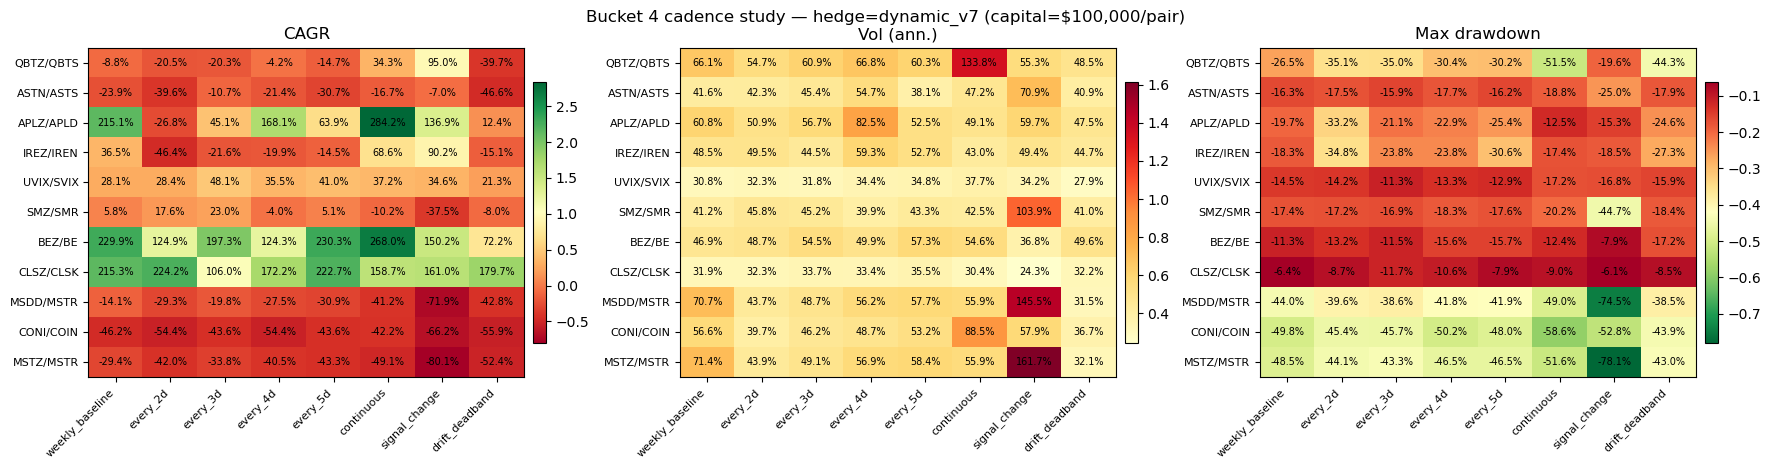

In [14]:
freq_pairs_order = [f"{k[0]}/{k[1]}" for k in CANDIDATE_KEYS if f"{k[0]}/{k[1]}" in set(FREQ["pair"])]


def freq_pivot(metric: str) -> pd.DataFrame:
    pv = FREQ.pivot(index="pair", columns="policy", values=metric)
    return pv.reindex(index=freq_pairs_order, columns=POLICY_ORDER)


fig, axes = plt.subplots(1, 3, figsize=(max(16, 2.2 * len(POLICY_ORDER)), max(4.0, 0.4 * len(freq_pairs_order))), constrained_layout=True)
for ax, metric, title, cmap in zip(
    axes,
    ["CAGR", "vol", "max_dd"],
    ["CAGR", "Vol (ann.)", "Max drawdown"],
    ["RdYlGn", "YlOrRd", "RdYlGn_r"],
):
    data = freq_pivot(metric).astype(float).values
    im = ax.imshow(data, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(POLICY_ORDER)))
    ax.set_xticklabels(POLICY_ORDER, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(freq_pairs_order)))
    ax.set_yticklabels(freq_pairs_order, fontsize=8)
    ax.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.1%}", ha="center", va="center", fontsize=7, color="black")
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
fig.suptitle(f"Bucket 4 cadence study — hedge={HEDGE} (capital=${EXP['per_pair_initial_capital']:,.0f}/pair)", fontsize=12, y=1.03)
plt.show()

### 7.3 Efficiency — trading effort vs return / drawdown

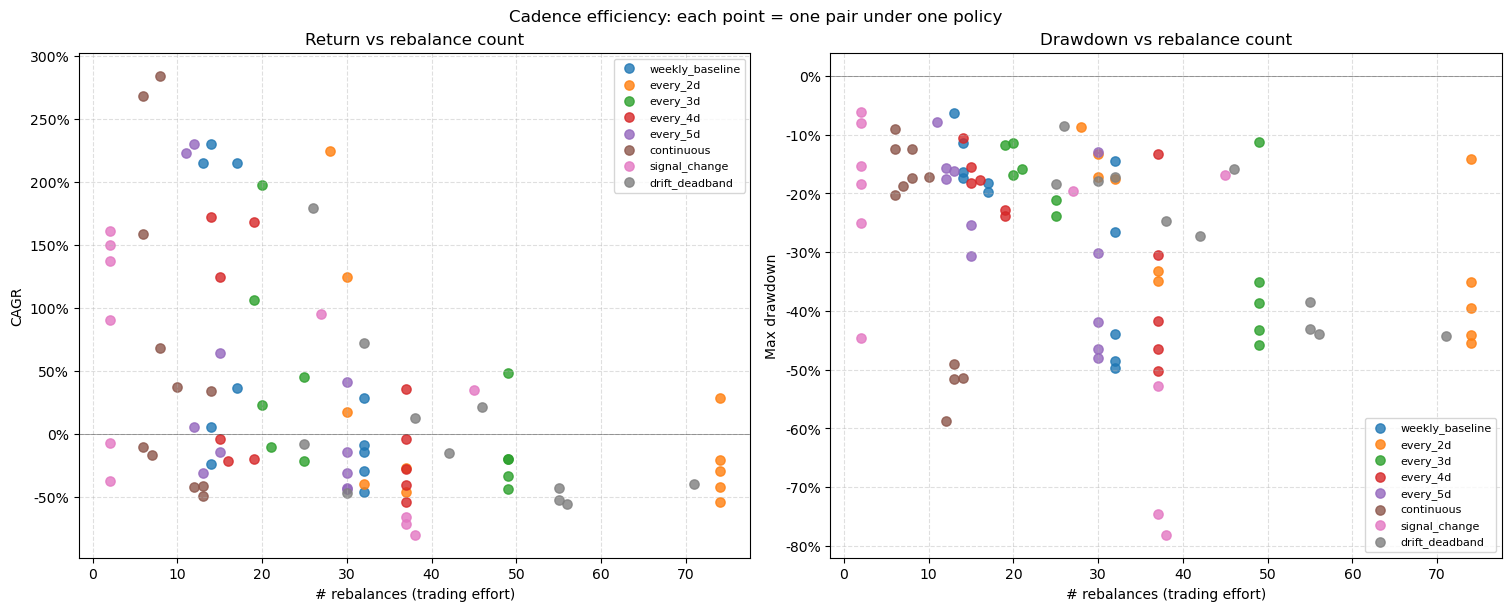

In [15]:
policy_colors = {p: c for p, c in zip(POLICY_ORDER, plt.rcParams["axes.prop_cycle"].by_key()["color"])}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
for policy in POLICY_ORDER:
    sub = FREQ[FREQ["policy"] == policy]
    if sub.empty:
        continue
    ax1.scatter(sub["n_rebalances"], sub["CAGR"], s=45, color=policy_colors[policy], label=policy, alpha=0.8)
    ax2.scatter(sub["n_rebalances"], sub["max_dd"], s=45, color=policy_colors[policy], label=policy, alpha=0.8)
for ax, ycol, ylab in ((ax1, "CAGR", "CAGR"), (ax2, "max_dd", "Max drawdown")):
    ax.set_xlabel("# rebalances (trading effort)")
    ax.set_ylabel(ylab)
    ax.axhline(0, color="k", lw=0.6, alpha=0.4)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=8)
ax1.set_title("Return vs rebalance count")
ax2.set_title("Drawdown vs rebalance count")
fig.suptitle("Cadence efficiency: each point = one pair under one policy", fontsize=12)
plt.show()

### 7.4 Signal overlay & equity for the top-weight pair

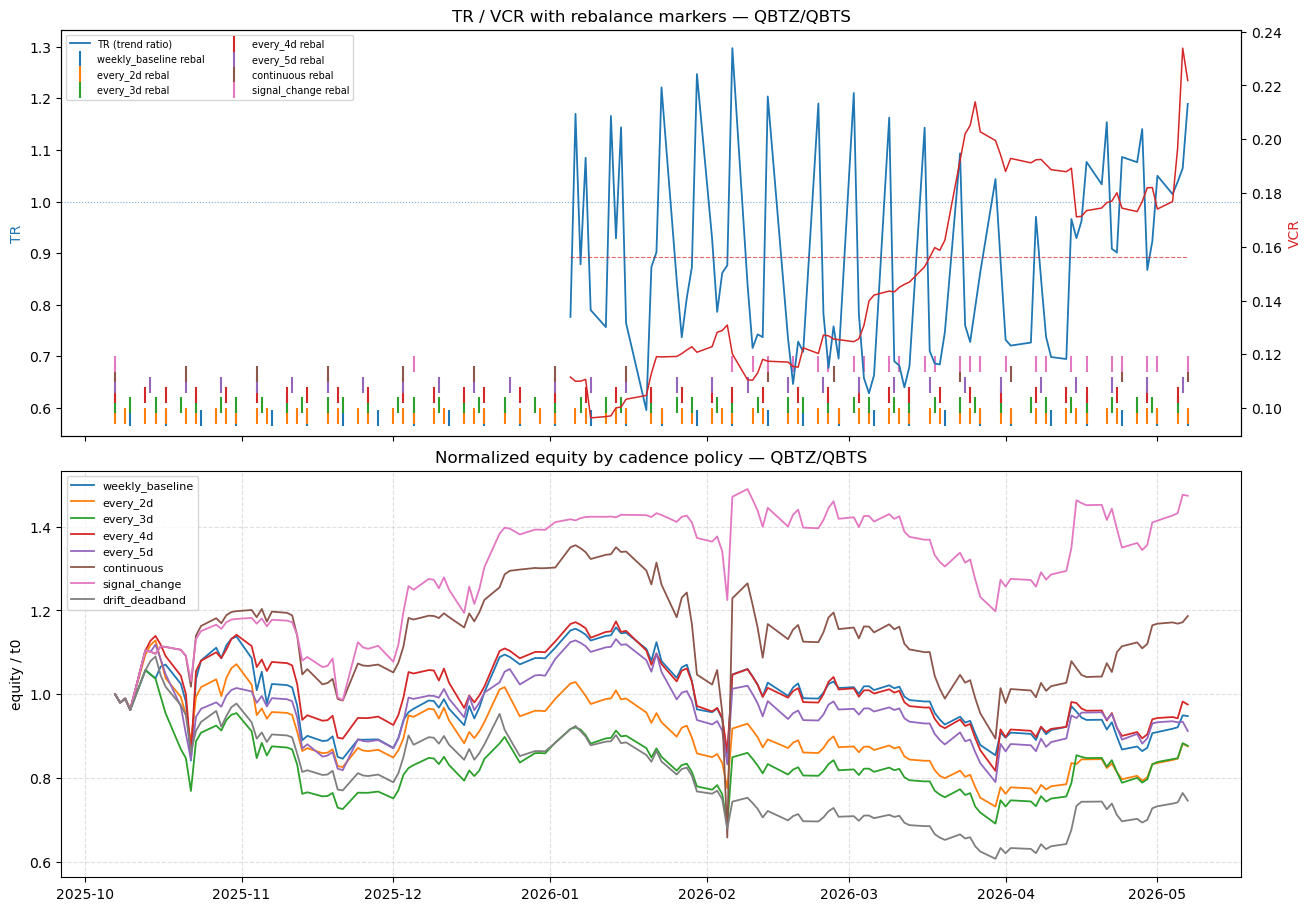

In [16]:
top_key = CANDIDATE_KEYS[0]
top_lab = f"{top_key[0]}/{top_key[1]}"
sig = SIGNALS.get(top_key)

fig, (axs, axe) = plt.subplots(2, 1, figsize=(13, 9), sharex=True, constrained_layout=True)
if sig is not None and sig["tr"].notna().any():
    axs.plot(sig.index, sig["tr"], color="tab:blue", lw=1.3, label="TR (trend ratio)")
    axs.axhline(1.0, color="tab:blue", ls=":", lw=0.8, alpha=0.6)
    axs.set_ylabel("TR", color="tab:blue")
    axv = axs.twinx()
    axv.plot(sig.index, sig["vcr"], color="tab:red", lw=1.1, label="VCR")
    axv.plot(sig.index, sig["vcr_med"], color="tab:red", ls="--", lw=0.8, alpha=0.7, label="VCR median")
    axv.set_ylabel("VCR", color="tab:red")
y0 = 0
_overlay_policies = [
    p for p in POLICY_ORDER if p in ("weekly_baseline", "continuous", "signal_change") or p.startswith("every_")
]
for policy in _overlay_policies:
    rd = freq_dates.get((top_lab, policy))
    if rd is None or len(rd) == 0:
        continue
    axs.scatter(rd, np.full(len(rd), axs.get_ylim()[0] + 0.02 * (y0 + 1)), marker="|", s=120, color=policy_colors[policy], label=f"{policy} rebal")
    y0 += 1
axs.set_title(f"TR / VCR with rebalance markers — {top_lab}")
axs.legend(loc="upper left", fontsize=7, ncol=2)

for policy in POLICY_ORDER:
    bt = freq_bt.get((top_lab, policy))
    if bt is None:
        continue
    eq = bt["equity"].astype(float)
    nrm = eq / float(eq.iloc[0]) if float(eq.iloc[0]) > 1e-9 else eq
    axe.plot(nrm.index, nrm.values, lw=1.3, color=policy_colors.get(policy), label=policy)
axe.set_title(f"Normalized equity by cadence policy — {top_lab}")
axe.set_ylabel("equity / t0")
axe.legend(fontsize=8)
axe.grid(True, linestyle="--", alpha=0.4)
plt.show()

### 7.5 Best cadence per pair vs weekly baseline

In [17]:
FREQ["ret_vol"] = FREQ["CAGR"] / FREQ["vol"].replace(0.0, np.nan)
best_cad = (
    FREQ.sort_values("ret_vol", ascending=False)
    .groupby("pair", as_index=False)
    .first()[["pair", "policy", "CAGR", "vol", "max_dd", "ret_vol", "n_rebalances"]]
    .rename(columns={"policy": "best_policy"})
)
base = FREQ[FREQ["policy"] == "weekly_baseline"].set_index("pair")
best_cad["baseline_CAGR"] = best_cad["pair"].map(base["CAGR"])
best_cad["baseline_max_dd"] = best_cad["pair"].map(base["max_dd"])
best_cad["CAGR_uplift"] = best_cad["CAGR"] - best_cad["baseline_CAGR"]
best_cad["dd_improvement"] = best_cad["baseline_max_dd"] - best_cad["max_dd"]

print("Best cadence per pair (by CAGR/vol) vs weekly baseline:")
display(
    best_cad.style.format(
        {
            "CAGR": "{:.2%}",
            "vol": "{:.2%}",
            "max_dd": "{:.2%}",
            "ret_vol": "{:.2f}",
            "n_rebalances": "{:.0f}",
            "baseline_CAGR": "{:.2%}",
            "baseline_max_dd": "{:.2%}",
            "CAGR_uplift": "{:+.2%}",
            "dd_improvement": "{:+.2%}",
        }
    )
)

print("\nMean metrics by policy (across pairs):")
display(
    FREQ.groupby("policy")[["CAGR", "vol", "max_dd", "ret_vol", "n_rebalances", "borrow_paid", "cost_paid"]]
    .mean()
    .reindex(POLICY_ORDER)
    .style.format({"CAGR": "{:.2%}", "vol": "{:.2%}", "max_dd": "{:.2%}", "ret_vol": "{:.2f}", "n_rebalances": "{:.1f}", "borrow_paid": "{:,.0f}", "cost_paid": "{:,.0f}"})
)

Best cadence per pair (by CAGR/vol) vs weekly baseline:


,pair,best_policy,CAGR,vol,max_dd,ret_vol,n_rebalances,baseline_CAGR,baseline_max_dd,CAGR_uplift,dd_improvement
0,APLZ/APLD,continuous,284.16%,49.13%,-12.51%,5.78,8,215.13%,-19.75%,+69.03%,-7.24%
1,ASTN/ASTS,signal_change,-7.00%,70.87%,-24.98%,-0.10,2,-23.91%,-16.28%,+16.91%,+8.70%
2,BEZ/BE,continuous,267.98%,54.64%,-12.41%,4.90,6,229.93%,-11.34%,+38.05%,+1.07%
3,CLSZ/CLSK,every_2d,224.22%,32.31%,-8.67%,6.94,28,215.32%,-6.37%,+8.89%,+2.29%
4,CONI/COIN,continuous,-42.24%,88.53%,-58.65%,-0.48,12,-46.20%,-49.78%,+3.96%,+8.87%
5,IREZ/IREN,signal_change,90.18%,49.44%,-18.47%,1.82,2,36.48%,-18.26%,+53.70%,+0.21%
6,MSDD/MSTR,weekly_baseline,-14.05%,70.73%,-43.98%,-0.20,32,-14.05%,-43.98%,+0.00%,+0.00%
7,MSTZ/MSTR,weekly_baseline,-29.41%,71.43%,-48.47%,-0.41,32,-29.41%,-48.47%,+0.00%,+0.00%
8,QBTZ/QBTS,signal_change,95.03%,55.29%,-19.59%,1.72,27,-8.82%,-26.50%,+103.86%,-6.91%
9,SMZ/SMR,every_3d,22.97%,45.18%,-16.92%,0.51,20,5.77%,-17.44%,+17.21%,-0.53%



Mean metrics by policy (across pairs):


,CAGR,vol,max_dd,ret_vol,n_rebalances,borrow_paid,cost_paid
policy,,,,,,,
weekly_baseline,55.31%,51.51%,-24.79%,1.35,22.6,"6,938",685
every_2d,12.39%,43.99%,-27.55%,0.45,51.3,"6,571",930
every_3d,24.51%,46.96%,-24.98%,0.59,34.1,"6,802",760
every_4d,29.83%,52.96%,-26.45%,0.68,25.7,"7,015",741
every_5d,35.03%,49.42%,-26.62%,0.85,20.7,"6,784",668
continuous,62.85%,58.06%,-28.93%,1.46,9.4,"7,154",518
signal_change,36.84%,72.69%,-32.66%,1.36,17.8,"7,113",500
drift_deadband,2.28%,39.32%,-27.23%,0.10,43.3,"6,432",980


## 8. Combined summary — dynamic_v7 + best cadence per pair


In [20]:
# Requires section 7.1 (FREQ) and 3b (H_V7_BY_PAIR)
import numpy as np
if "FREQ" not in globals() or FREQ.empty:
    raise RuntimeError("Run section 7.1 cadence sweep first.")

FREQ["ret_vol"] = FREQ["CAGR"] / FREQ["vol"].replace(0, np.nan)
best = (
    FREQ.sort_values("ret_vol", ascending=False)
    .groupby("pair", as_index=False)
    .first()[["pair", "policy", "CAGR", "vol", "max_dd", "ret_vol", "n_rebalances"]]
    .rename(columns={"policy": "best_cadence_policy"})
)
base = FREQ[(FREQ["policy"] == "weekly_baseline")].set_index("pair")
best["baseline_CAGR"] = best["pair"].map(base["CAGR"])
best["CAGR_uplift_vs_weekly"] = best["CAGR"] - best["baseline_CAGR"]

# v6 vs v7 on weekly + same cadence (optional quick compare if RESULTS exists)
if "RESULTS" in globals() and not RESULTS.empty:
    cmp = RESULTS[RESULTS["hedge_method"].isin(["dynamic_v6", "dynamic_v7"])].pivot_table(
        index="pair", columns="hedge_method", values="CAGR"
    )
    if not cmp.empty:
        cmp["v7_minus_v6"] = cmp.get("dynamic_v7", np.nan) - cmp.get("dynamic_v6", np.nan)
        print("Hedge level grid (weekly rebal): v7 - v6 CAGR")
        display(cmp.style.format("{:.2%}"))

print(f"Cadence study hedge={EXP.get('cadence_hedge_method')} | global h in [{EXP['v7_global_h_min']}, {EXP['v7_global_h_max']}]")
display(
    best.style.format({
        "CAGR": "{:.2%}", "vol": "{:.2%}", "max_dd": "{:.2%}", "ret_vol": "{:.2f}",
        "n_rebalances": "{:.0f}", "baseline_CAGR": "{:.2%}", "CAGR_uplift_vs_weekly": "{:+.2%}",
    })
)

Hedge level grid (weekly rebal): v7 - v6 CAGR


hedge_method,dynamic_v6,dynamic_v7,v7_minus_v6
pair,,,
APLZ/APLD,234.56%,258.11%,23.55%
ASTN/ASTS,-10.11%,-23.05%,-12.93%
BEZ/BE,119.57%,197.63%,78.07%
CLSZ/CLSK,267.72%,250.76%,-16.96%
CONI/COIN,-27.26%,-46.19%,-18.93%
IREZ/IREN,52.80%,67.50%,14.70%
MSDD/MSTR,-0.40%,-18.04%,-17.64%
MSTZ/MSTR,-17.42%,-32.38%,-14.96%
QBTZ/QBTS,-1.98%,-16.80%,-14.81%


Cadence study hedge=dynamic_v7 | global h in [0.3, 0.8]


,pair,best_cadence_policy,CAGR,vol,max_dd,ret_vol,n_rebalances,baseline_CAGR,CAGR_uplift_vs_weekly
0,APLZ/APLD,continuous,284.16%,49.13%,-12.51%,5.78,8,215.13%,+69.03%
1,ASTN/ASTS,signal_change,-7.00%,70.87%,-24.98%,-0.10,2,-23.91%,+16.91%
2,BEZ/BE,continuous,267.98%,54.64%,-12.41%,4.90,6,229.93%,+38.05%
3,CLSZ/CLSK,every_2d,224.22%,32.31%,-8.67%,6.94,28,215.32%,+8.89%
4,CONI/COIN,continuous,-42.24%,88.53%,-58.65%,-0.48,12,-46.20%,+3.96%
5,IREZ/IREN,signal_change,90.18%,49.44%,-18.47%,1.82,2,36.48%,+53.70%
6,MSDD/MSTR,weekly_baseline,-14.05%,70.73%,-43.98%,-0.20,32,-14.05%,+0.00%
7,MSTZ/MSTR,weekly_baseline,-29.41%,71.43%,-48.47%,-0.41,32,-29.41%,+0.00%
8,QBTZ/QBTS,signal_change,95.03%,55.29%,-19.59%,1.72,27,-8.82%,+103.86%
9,SMZ/SMR,every_3d,22.97%,45.18%,-16.92%,0.51,20,5.77%,+17.21%
